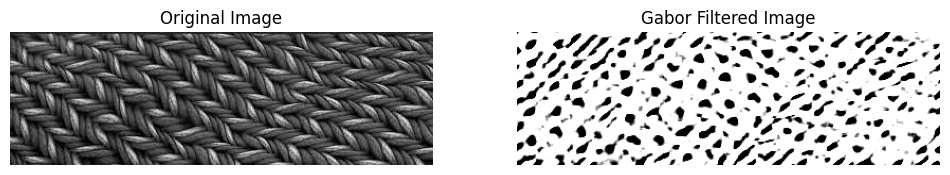

In [1]:
# Code Example 1: Texture Analysis for Surface Defect Detection
import cv2 
import numpy as np 
import matplotlib.pyplot as plt
gray = cv2.imread("D:/23108106/A24.jpg", cv2.IMREAD_GRAYSCALE)
kernel = cv2.getGaborKernel(ksize=(21, 21), sigma=8.0, theta=np.pi/4, lambd=10.0, gamma=0.5, psi=0, ktype=cv2.CV_32F)
filtered = cv2.filter2D(gray, cv2.CV_8UC3, kernel) 
plt.figure(figsize=(12, 6)) 
plt.subplot(1, 2, 1) 
plt.imshow(gray, cmap='gray') 
plt.title('Original Image') 
plt.axis('off') 
plt.subplot(1, 2, 2) 
plt.imshow(filtered, cmap='gray') 
plt.title('Gabor Filtered Image') 
plt.axis('off') 
plt.show()

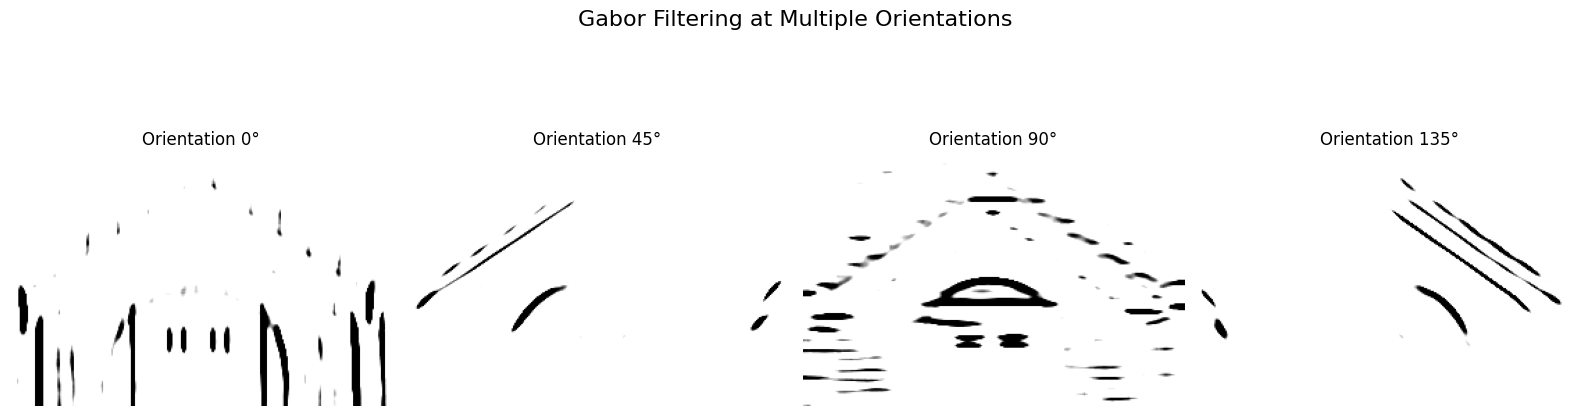

In [2]:
# Code Example 2: Automated Architectural Surface Texture Analysis Using Gabor Filters
import cv2 
import numpy as np 
import matplotlib.pyplot as plt
gray = cv2.imread("D:/23108106/A25.jpg", cv2.IMREAD_GRAYSCALE)
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4] 
plt.figure(figsize=(16, 5)) 
for i, theta in enumerate(orientations): 
    kernel = cv2.getGaborKernel((21, 21), 4.0, theta, 10.0, 0.5, 0, ktype=cv2.CV_32F) 
    filtered_img = cv2.filter2D(gray, cv2.CV_8UC3, kernel) 
    plt.subplot(1, 4, i+1) 
    plt.imshow(filtered_img, cmap='gray') 
    plt.title(f"Orientation {int(np.degrees(theta))}°") 
    plt.axis('off') 
plt.suptitle('Gabor Filtering at Multiple Orientations', fontsize=16) 
plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

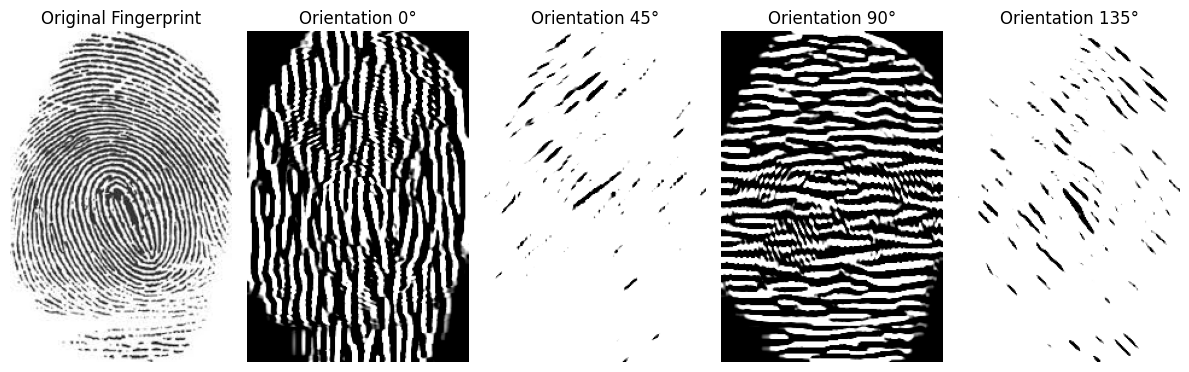

In [3]:
# Code Example 3: Fingerprint Ridge Enhancement Using Gabor Filters for Minutiae Detection
import cv2 
import numpy as np 
import matplotlib.pyplot as plt
img = cv2.imread("D:/23108106/A26.jpg", cv2.IMREAD_GRAYSCALE) 
if img is None: 
    print("Error loading image.") 
else: 
    kernel_size = 21 
    sigma = 5.0  
    lambd = 10.0 
    gamma = 0.5 
    psi = 0
    orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4] 
    filtered_imgs = [] 
    plt.figure(figsize=(12, 6)) 
    plt.subplot(1, len(orientations)+1, 1) 
    plt.title("Original Fingerprint") 
    plt.imshow(img, cmap='gray') 
    plt.axis('off') 
    for i, theta in enumerate(orientations): 
        kernel = cv2.getGaborKernel((kernel_size, kernel_size), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F) 
        filtered_img = cv2.filter2D(img, cv2.CV_8UC3, kernel)
        filtered_imgs.append(filtered_img) 
        plt.subplot(1, len(orientations)+1, i+2) 
        plt.title(f"Orientation {int(np.degrees(theta))}°") 
        plt.imshow(filtered_img, cmap='gray') 
        plt.axis('off') 
    plt.tight_layout() 
    plt.show()

Total samples: 60

Classification Report:

              precision    recall  f1-score   support

      banded       0.40      1.00      0.57         2
     blotchy       0.20      0.50      0.29         2
     braided       0.00      0.00      0.00         3
      bubbly       0.00      0.00      0.00         3
       bumpy       0.00      0.00      0.00         3
   chequered       0.00      0.00      0.00         2

    accuracy                           0.20        15
   macro avg       0.10      0.25      0.14        15
weighted avg       0.08      0.20      0.11        15


Accuracy: 20.00%


C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

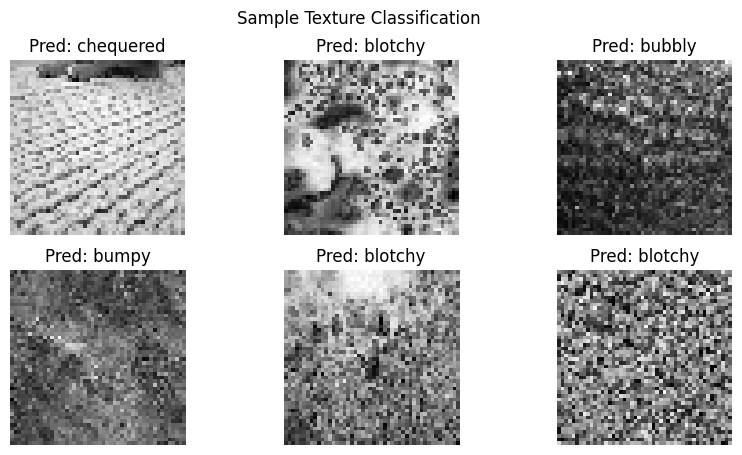

In [4]:
# Code Example 4: Texture Classification for Industrial Quality Inspection Using Gabor Features
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
def gabor_features(img, kernels):
    features = []
    img = img.astype(np.float32)
    for kernel in kernels:
        filtered = cv2.filter2D(img, cv2.CV_32F, kernel)
        features.append(filtered.mean())
        features.append(filtered.var())  
    return features
dataset_path = "D:/23108106/dtd/images"
kernel_size = 15
sigmas = [4.0]
lambdas = [10.0]
orientations = [0, np.pi/2]
kernels = [
    cv2.getGaborKernel(
        (kernel_size, kernel_size),
        sigma,
        theta,
        lambd,
        0.5,
        0,
        ktype=cv2.CV_32F
    )
    for sigma in sigmas
    for lambd in lambdas
    for theta in orientations
]
X, y, images = [], [], []
label_map = {}
label_id = 0
for class_name in os.listdir(dataset_path)[:6]:
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        label_map[label_id] = class_name
        for img_name in os.listdir(class_path)[:10]:  
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (48, 48)) 
                features = gabor_features(img, kernels)
                X.append(features)
                y.append(label_id)
                images.append(img)
        label_id += 1
X = np.array(X)
y = np.array(y)
print("Total samples:", len(X))
X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X, y, images,
    test_size=0.25,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
clf = SVC(kernel='rbf', C=1.0, gamma='scale')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("\nClassification Report:\n")
labels = np.unique(y_test)
print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=[label_map[i] for i in labels]
))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
plt.figure(figsize=(10, 5))
for i in range(min(6, len(img_test))):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_test[i], cmap='gray')
    plt.title(f"Pred: {label_map[y_pred[i]]}")
    plt.axis('off')
plt.suptitle("Sample Texture Classification")
plt.show()

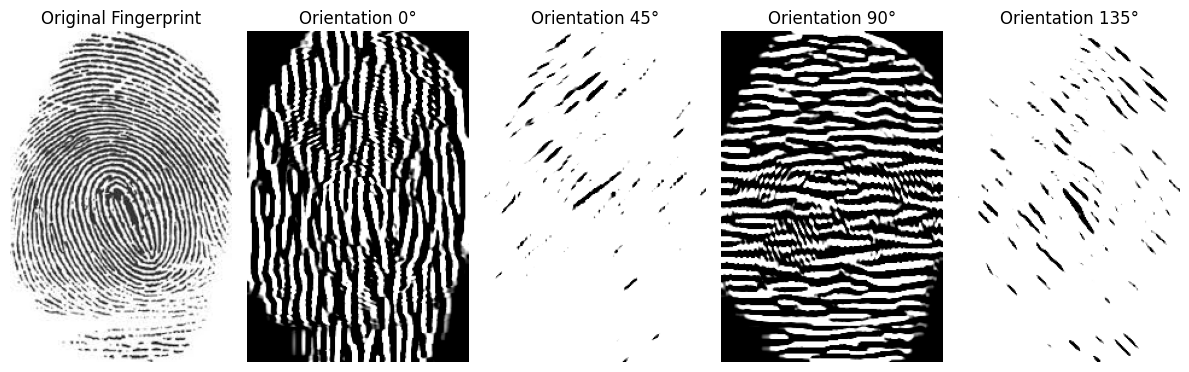

In [5]:
# 1. Fingerprint Ridge Enhancement for Forensic Applications
import cv2 
import numpy as np 
import matplotlib.pyplot as plt
img = cv2.imread("D:/23108106/A26.jpg", cv2.IMREAD_GRAYSCALE) 
if img is None: 
    print("Error loading image.") 
else: 
    kernel_size = 21 
    sigma = 5.0  
    lambd = 10.0 
    gamma = 0.5 
    psi = 0
    orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4] 
    filtered_imgs = [] 
    plt.figure(figsize=(12, 6)) 
    plt.subplot(1, len(orientations)+1, 1) 
    plt.title("Original Fingerprint") 
    plt.imshow(img, cmap='gray') 
    plt.axis('off') 
    for i, theta in enumerate(orientations): 
        kernel = cv2.getGaborKernel((kernel_size, kernel_size), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F) 
        filtered_img = cv2.filter2D(img, cv2.CV_8UC3, kernel)
        filtered_imgs.append(filtered_img) 
        plt.subplot(1, len(orientations)+1, i+2) 
        plt.title(f"Orientation {int(np.degrees(theta))}°") 
        plt.imshow(filtered_img, cmap='gray') 
        plt.axis('off') 
    plt.tight_layout() 
    plt.show()

Total samples: 60

Classification Report:

              precision    recall  f1-score   support

      banded       0.40      1.00      0.57         2
     blotchy       0.20      0.50      0.29         2
     braided       0.00      0.00      0.00         3
      bubbly       0.00      0.00      0.00         3
       bumpy       0.00      0.00      0.00         3
   chequered       0.00      0.00      0.00         2

    accuracy                           0.20        15
   macro avg       0.10      0.25      0.14        15
weighted avg       0.08      0.20      0.11        15


Accuracy: 20.00%


C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

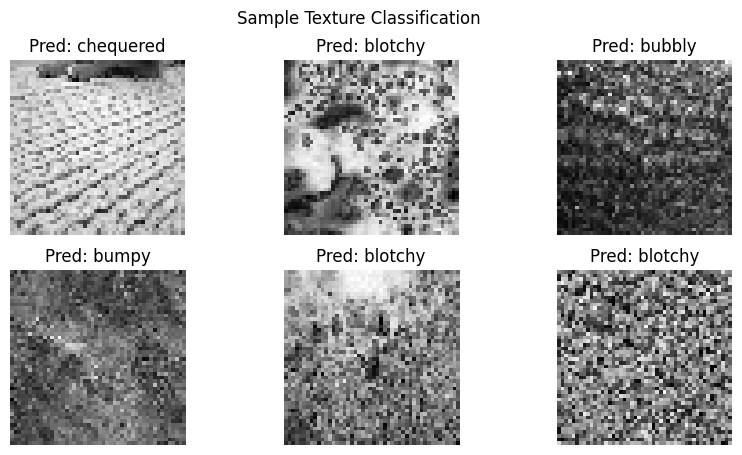

In [6]:
# 2. Texture Classification in Industrial Quality Control
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
def gabor_features(img, kernels):
    features = []
    img = img.astype(np.float32)
    for kernel in kernels:
        filtered = cv2.filter2D(img, cv2.CV_32F, kernel)
        features.append(filtered.mean())
        features.append(filtered.var())  
    return features
dataset_path = "D:/23108106/dtd/images"
kernel_size = 15
sigmas = [4.0]
lambdas = [10.0]
orientations = [0, np.pi/2]
kernels = [
    cv2.getGaborKernel(
        (kernel_size, kernel_size),
        sigma,
        theta,
        lambd,
        0.5,
        0,
        ktype=cv2.CV_32F
    )
    for sigma in sigmas
    for lambd in lambdas
    for theta in orientations
]
X, y, images = [], [], []
label_map = {}
label_id = 0
for class_name in os.listdir(dataset_path)[:6]:
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        label_map[label_id] = class_name
        for img_name in os.listdir(class_path)[:10]:  
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (48, 48)) 
                features = gabor_features(img, kernels)
                X.append(features)
                y.append(label_id)
                images.append(img)
        label_id += 1
X = np.array(X)
y = np.array(y)
print("Total samples:", len(X))
X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X, y, images,
    test_size=0.25,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
clf = SVC(kernel='rbf', C=1.0, gamma='scale')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("\nClassification Report:\n")
labels = np.unique(y_test)
print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=[label_map[i] for i in labels]
))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
plt.figure(figsize=(10, 5))
for i in range(min(6, len(img_test))):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_test[i], cmap='gray')
    plt.title(f"Pred: {label_map[y_pred[i]]}")
    plt.axis('off')
plt.suptitle("Sample Texture Classification")
plt.show()

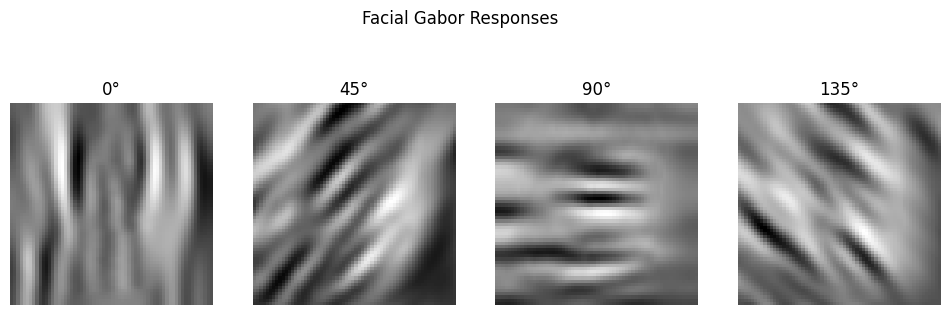

Feature Vector: [np.float32(852.7073), np.float32(1338325.5), np.float32(1732.9745), np.float32(653003.0), np.float32(861.56793), np.float32(496378.44), np.float32(1721.4574), np.float32(613616.9)]


In [7]:
# 3. Facial Expression Recognition for Mental Health Analysis
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("D:/23108106/A16.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (64, 64))
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
plt.figure(figsize=(12,4))
features = []
for i, theta in enumerate(orientations):
    kernel = cv2.getGaborKernel((21,21), 4.0, theta, 10.0, 0.5, 0, ktype=cv2.CV_32F)
    filtered = cv2.filter2D(img, cv2.CV_32F, kernel)
    features.append(filtered.mean())
    features.append(filtered.var())
    plt.subplot(1,4,i+1)
    plt.imshow(filtered, cmap='gray')
    plt.title(f"{int(np.degrees(theta))}°")
    plt.axis('off')
plt.suptitle("Facial Gabor Responses")
plt.show()
print("Feature Vector:", features)

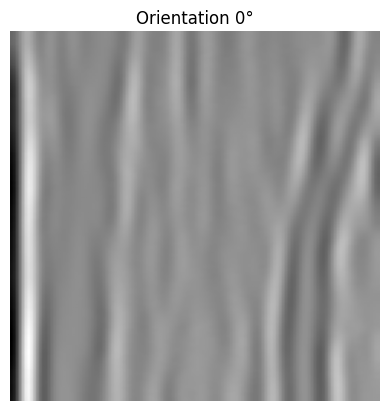

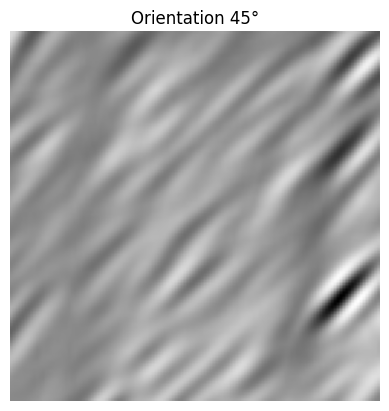

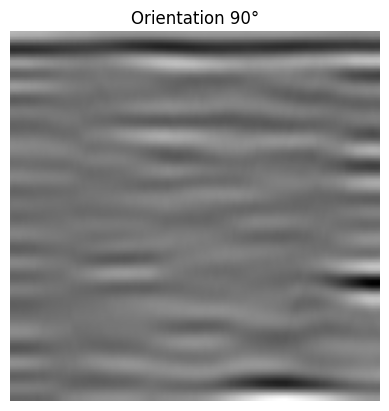

Texture Response Values: [np.float32(1025.7257), np.float32(1503.5099), np.float32(1070.2217)]
Detected: Forest Region


In [8]:
# 4. Texture-Based Segmentation of Satellite Images
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("D:/23108106/A7.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128, 128))
orientations = [0, np.pi/4, np.pi/2]
responses = []
for theta in orientations:
    kernel = cv2.getGaborKernel((31,31), 5.0, theta, 12.0, 0.5, 0)
    filtered = cv2.filter2D(img, cv2.CV_32F, kernel)
    responses.append(filtered)
    plt.imshow(filtered, cmap='gray')
    plt.title(f"Orientation {int(np.degrees(theta))}°")
    plt.axis('off')
    plt.show()
avg_response = [np.mean(r) for r in responses]
print("Texture Response Values:", avg_response)
if max(avg_response) == avg_response[0]:
    print("Detected: Water Region")
elif max(avg_response) == avg_response[1]:
    print("Detected: Forest Region")
else:
    print("Detected: Urban Region")

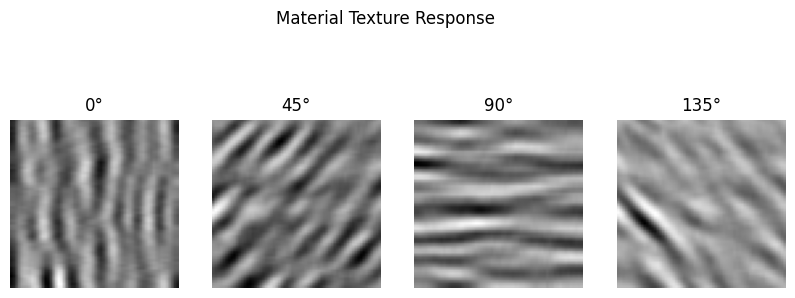

Feature Vector: [np.float32(-233.58585), np.float32(115475.695), np.float32(967.2897), np.float32(184818.5), np.float32(-228.55661), np.float32(753544.5), np.float32(961.4136), np.float32(207658.58)]
Predicted: Brick


In [9]:
# 5. Architectural Material Recognition in Restoration Projects
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("D:/23108106/A27.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (64, 64))
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
features = []
plt.figure(figsize=(10,4))
for i, theta in enumerate(orientations):
    kernel = cv2.getGaborKernel((21,21), 6.0, theta, 10.0, 0.5, 0)
    filtered = cv2.filter2D(img, cv2.CV_32F, kernel)
    features.append(np.mean(filtered))
    features.append(np.var(filtered))
    plt.subplot(1,4,i+1)
    plt.imshow(filtered, cmap='gray')
    plt.title(f"{int(np.degrees(theta))}°")
    plt.axis('off')
plt.suptitle("Material Texture Response")
plt.show()
print("Feature Vector:", features)
if np.mean(features) > 0.2:
    print("Predicted: Brick")
else:
    print("Predicted: Plaster / Wood")